In [51]:
import tensorflow as tf # tensorflow is normally pre installed by google colab by default

print(tf.__version__)

2.21.0


In [52]:
# import some basic libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [53]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


This a binary classification where we will be predicting exited

In [54]:
# diving the dependent and independent features
X = df.iloc[:, 3:13] # getting from 3rd column to 12th column
# We are not using the RowNumber, CustomerId and Surname, cause they do not effect the context at all

y = df.iloc[:, 13] # getting the 13th column

In [55]:
X.head() # independent features

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [56]:
y

,Exited
0,1
1,0
2,1
3,0
4,0
...,...
9995,0
9996,0
9997,1
9998,1


In [57]:
# Feat engineering
geography = pd.get_dummies(X['Geography'], drop_first=True) # similar to one hoe encoding slightly different by concept
gender = pd.get_dummies(X['Gender'], drop_first=True)

In [58]:
geography

,Germany,Spain
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True
...,...,...
9995,False,False
9996,False,False
9997,False,False
9998,True,False


In [59]:
gender

,Male
0,False
1,False
2,False
3,False
4,False
...,...
9995,True
9996,True
9997,False
9998,True


In [60]:
# Concat these endoded variables into the data frame
X = X.drop(['Geography', 'Gender'], axis=1) # drop both Gender and Geography

In [61]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [62]:
X=pd.concat([X,geography,gender],axis=1) # adding the encoded categorical variables

In [63]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [64]:
# Splitting the dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
# Feat Scaling is also required for ANN
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train) # will fit for the data calculate standard deviation .. etc and all and then transform
X_test = sc.transform(X_test) # Does not fit the data only transfrom using eariler values, cause then it will no nothing about the test data which we want

In [66]:
X_train

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [67]:
X_test

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [68]:
X_train.shape

(8000, 11)

Data Preprocessing is done, so we can start building an ANN

In [69]:
from tensorflow.keras.models import Sequential # used for forward and backwards propogation
from tensorflow.keras.layers import Dense # this class is used to create the individual neurons in the layers
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU # activation functions
from tensorflow.keras.layers import Dropout
# ANN can easily overfit during training.
# Dropout randomly deactivates a configured percentage of neurons
# during each training step, helping reduce overfitting.

In [70]:
# Initialising the ANN
classifier = Sequential()

In [71]:
# Adding input layer
classifier.add(Dense(units=11, activation='relu')) # 11 units cause there are 11 input features

In [72]:
# adding 1st hidden layer
classifier.add(Dense(units=7, activation='relu'))
classifier.add(Dropout(0.3)) # adding dropout to avoid overfitting to this layer, similarlly you can add dropout to other layers as well if needed

In [73]:
# adding 2nd hidden layer
classifier.add(Dense(units=6, activation='relu'))

In [74]:
# adding the output layer
classifier.add(Dense(units=1, activation='sigmoid')) # sigmoid is ideal for binary classification, and 1 unit for the output layer

In [75]:
opt = tf.keras.optimizers.Adam(learning_rate=0.01) # customizing the default lrarning rate 0.01 in adam to 0.1

In [76]:
classifier.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy']) # passing the customised adam into to the classifier, we can also pass the default one if needed

In [77]:
# We have no clue on how much the epochs are needed for an ANN.. it will vary and the answer for that is not simple
# There is a concept called early stopping to tackle this

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", # basically stop trainig the ANN when there is no increments in the validation
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [78]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=100, callbacks=early_stopping)
# batch size is basically the data points passed into a single epoch
# an epoch is 1 cycle of forward and backwards propogation

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8048 - loss: 0.4570 - val_accuracy: 0.8107 - val_loss: 0.4041
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8153 - loss: 0.4079 - val_accuracy: 0.8289 - val_loss: 0.3996
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8235 - loss: 0.3974 - val_accuracy: 0.8311 - val_loss: 0.3919
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8276 - loss: 0.3949 - val_accuracy: 0.8448 - val_loss: 0.3860
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8410 - loss: 0.3811 - val_accuracy: 0.8376 - val_loss: 0.3803
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8360 - loss: 0.3808 - val_accuracy: 0.8493 - val_loss: 0.3686
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8354 - loss: 0.3745 - val_accuracy: 0.8448 - val_loss: 0.3670
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8408 - loss: 0.3730 - val_accu

A cool thing that I noticed as you can see there are 536 iterations in an epoch
**why?**
- the X_train has 8000 rows
- and we have defined that 0.33 (33%) is for validation, so for training we have 0.67

*8000 * 0.67 = 5360*

and there are 10 rows per batch as per our configuration.. so in 1 epoch we have 536 iterations


In [79]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

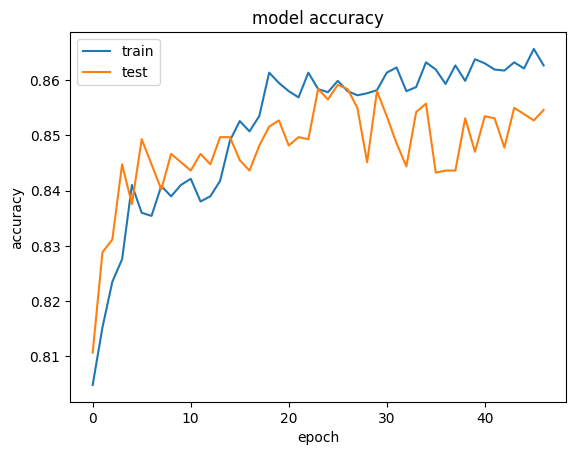

In [80]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

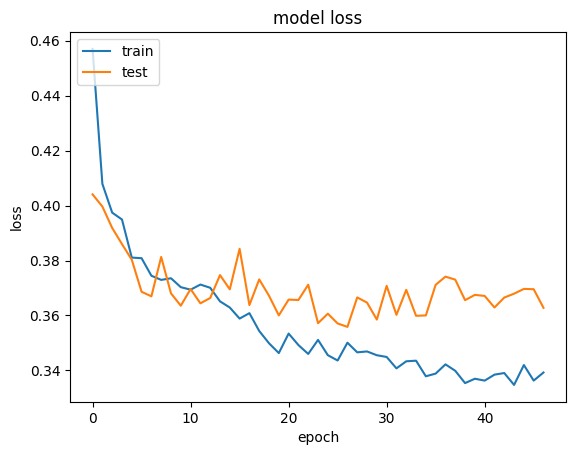

In [81]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [82]:
# Making the predictions and evaluating the model

# Predicting the Test set results
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5) # 0.5 is considered as the threshold for binary classification

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [83]:
# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1563,   44],
       [ 238,  155]])

In [84]:
# Calculate the Accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)

In [85]:
score

0.859

In [86]:
classifier.get_weights() # the weights of all the conections

[array([[-0.03864644, -0.41322184,  0.282587  , -0.15707202, -0.19294265,
         -1.1486982 , -0.40171406, -0.3081903 ,  0.13461642,  1.3325986 ,
         -0.13753594],
        [ 0.2181773 , -2.1081908 , -0.11572999,  2.8210077 ,  1.1284425 ,
         -1.3008249 ,  3.1550872 , -2.3387887 , -1.4563054 , -0.27452704,
         -1.0084977 ],
        [-0.07968586,  0.69088095,  0.44687915,  0.09822078, -0.02853525,
         -0.44882846,  0.02860437, -0.60887825,  1.0848763 , -0.19919212,
         -0.14832129],
        [ 1.1057723 ,  0.3580855 , -2.802135  , -0.3138814 ,  1.1316978 ,
         -0.05302498, -0.58788466, -0.28892726,  0.06313769, -0.72932965,
         -1.3671508 ],
        [-2.1097605 , -1.6060531 , -2.2752683 , -0.20914346,  3.8846154 ,
         -0.27761552, -2.9635046 , -0.49831688,  0.29920843,  0.7849633 ,
          1.0949551 ],
        [ 1.4435073 , -1.1419257 ,  0.2054046 ,  0.09864941, -0.08709484,
         -0.01193583,  0.25423622,  1.3225038 ,  1.0495807 ,  0.012021 